In [2]:
import geopandas as gpd
import pandas as pd

# display all columns
pd.set_option('display.max_columns', None)

TARGET = 'tceq'

# load the dataset
gdf = gpd.read_file(f'D:/tierra/datasets/mexico_{TARGET}_dataset_add_soil_features.geojson')

if TARGET == 'orgc':
    gdf.drop(columns=['tceq'], axis=1, inplace=True, errors='ignore')
elif TARGET == 'tceq':
    gdf.drop(columns=['orgc'], axis=1, inplace=True, errors='ignore')

gdf.head()

,date,longitude,latitude,upper_depth,lower_depth,clay,elcosp,phaq,sand,silt,tceq,temperature,precipitation,landcover,ecoregion,slopemean,soil_type,bedrock,rock_fragments,geometry
0,6/11/2001,-115.07201,31.415775,0,10,3.0,0.1,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,1.012489,FLUVISOL CALCARICO,rocas_sedimentarias,18.449413,POINT (-115.07201 31.41578)
1,6/11/2001,-115.07201,31.415775,0,10,3.0,0.1,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,1.012489,FLUVISOL CALCARICO,rocas_sedimentarias,15.816959,POINT (-115.07201 31.41578)
2,6/11/2001,-115.07201,31.415775,0,10,3.0,0.1,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,1.012489,FLUVISOL CALCARICO,rocas_sedimentarias,15.816959,POINT (-115.07201 31.41578)
3,6/12/2001,-111.33557,31.122982,0,23,22.0,0.1,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5,3.104057,LITOSOL,rocas_igneas,24.819817,POINT (-111.33557 31.12298)
4,6/12/2001,-111.33557,31.122982,0,23,22.0,0.1,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5,3.104057,LITOSOL,rocas_igneas,23.972266,POINT (-111.33557 31.12298)


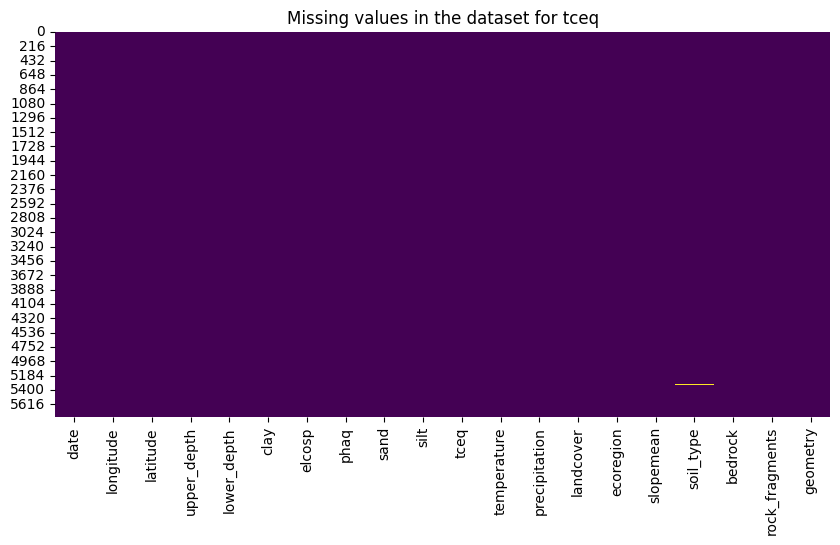

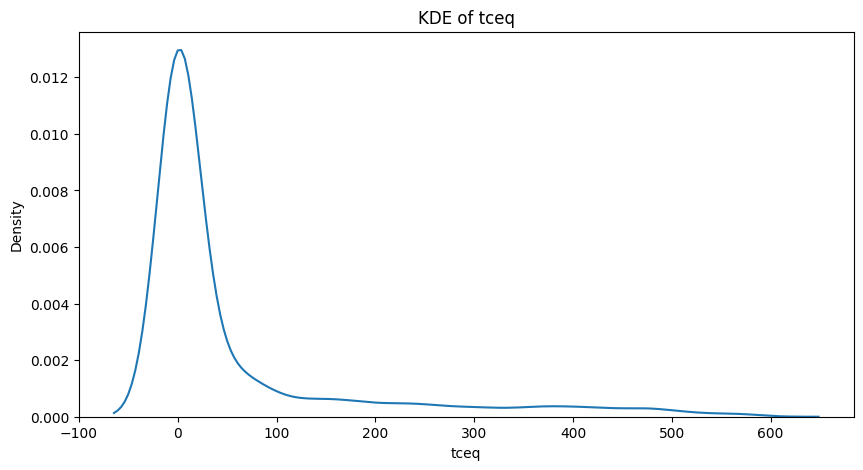

In [3]:
# plot missing values in the dataset
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.heatmap(gdf.isnull(), cbar=False, cmap='viridis')
plt.title(f'Missing values in the dataset for {TARGET}')
plt.show()

# plot kde of the target variable
plt.figure(figsize=(10, 5))
sns.kdeplot(gdf[TARGET])
plt.title(f'KDE of {TARGET}')
plt.show()

In [4]:
# Compute mean rock_fragments per (latitude, longitude) and map back to the dataset
gdf['rock_fragments'] = gdf.groupby(['latitude', 'longitude'])['rock_fragments'].transform('mean')

# drop irrelevant columns
gdf.drop(columns=['geometry', 'latitude', 'longitude', 'date'], axis=1, inplace=True, errors='ignore')

# Drop rows with missing values
gdf.dropna(inplace=True)
print('After dropping rows with missing values:', gdf.shape)

# Drop duplicate rows
gdf.drop_duplicates(inplace=True)
print('After dropping duplicate rows:', gdf.shape)

# Reset index
gdf.reset_index(drop=True, inplace=True)

gdf.head()


After dropping rows with missing values: (5772, 16)
After dropping duplicate rows: (1701, 16)


,upper_depth,lower_depth,clay,elcosp,phaq,sand,silt,tceq,temperature,precipitation,landcover,ecoregion,slopemean,soil_type,bedrock,rock_fragments
0,0,10,3.0,0.1,8.1,95.0,2.0,5.0,16.924751,150.516754,10.0,5,1.012489,FLUVISOL CALCARICO,rocas_sedimentarias,16.694444
1,0,23,22.0,0.1,8.7,56.0,22.0,10.0,16.924751,150.516754,7.0,5,3.104057,LITOSOL,rocas_igneas,24.254783
2,0,20,12.0,0.1,5.5,72.0,16.0,0.0,16.924751,150.516754,10.0,4,2.679646,REGOSOL EUTRICO,rocas_metamorficas,16.670178
3,0,20,32.0,0.1,6.4,54.0,14.0,0.0,16.924751,150.516754,7.0,5,0.959081,FEOZEM HAPLICO,rocas_sedimentarias,20.084764
4,0,15,20.0,0.2,6.4,64.0,16.0,0.0,16.924751,150.516754,10.0,5,1.089010,FEOZEM HAPLICO,rocas_sedimentarias,16.089236



Baseline Model:
MSE: 11713.2533
MAE: 81.4050
R2: -0.0066


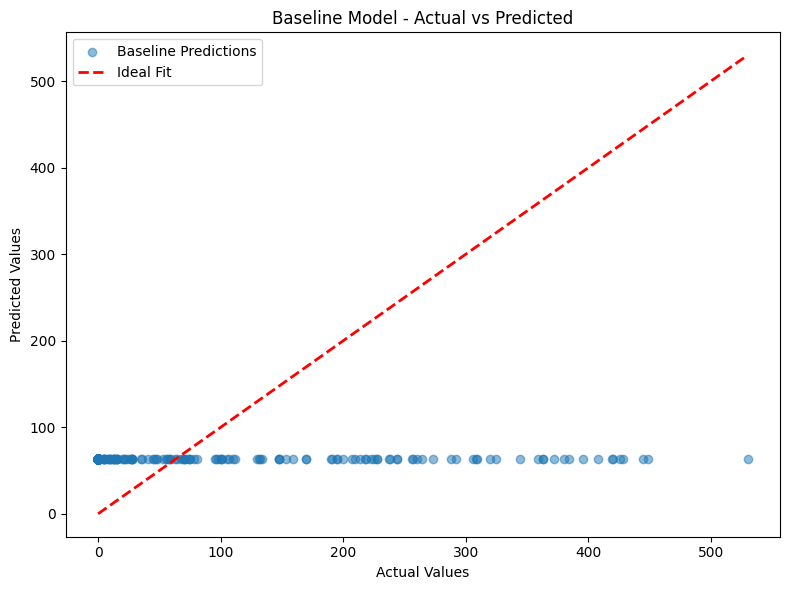


Training Random Forest...
MSE: 4547.3690
MAE: 33.1858
R2: 0.6092


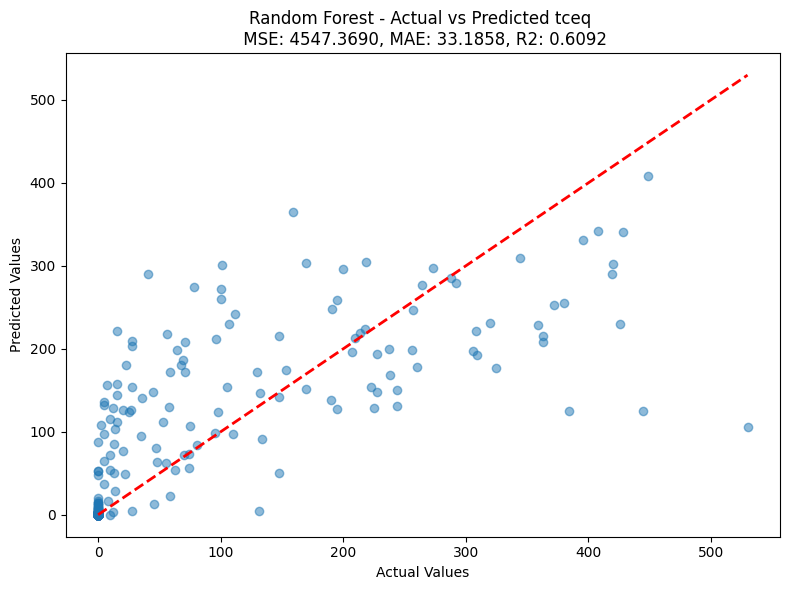

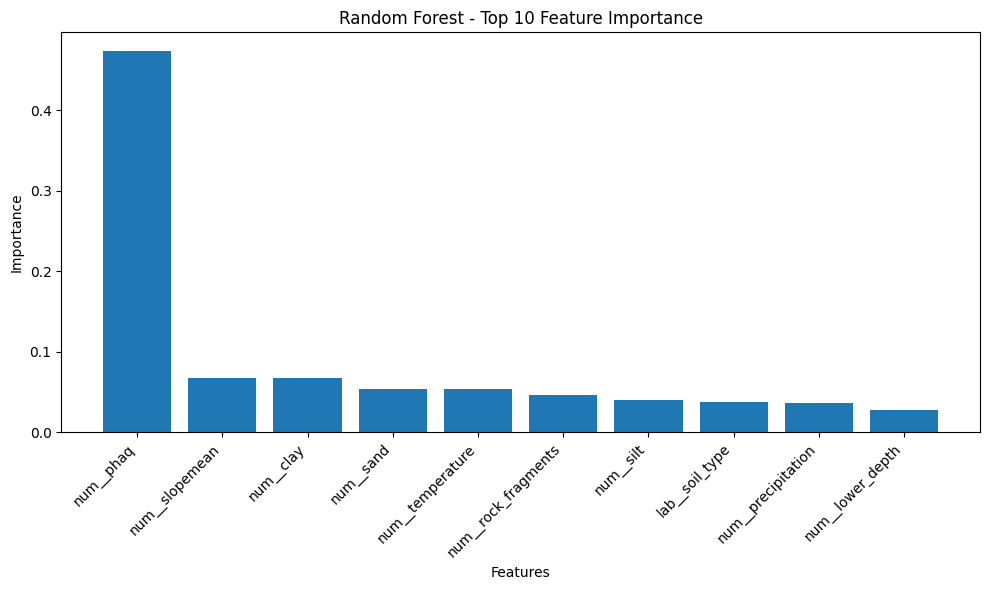


Training Gradient Boosting...
MSE: 5578.7093
MAE: 39.5923
R2: 0.5206


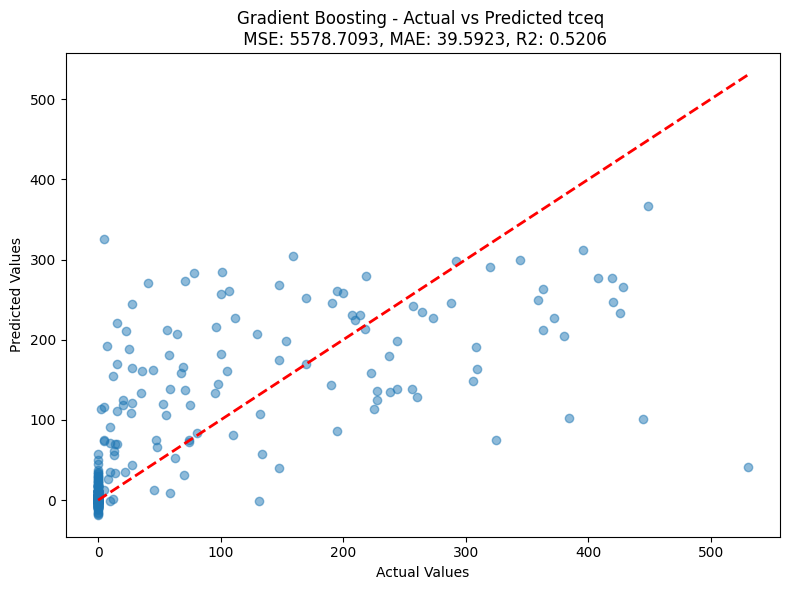

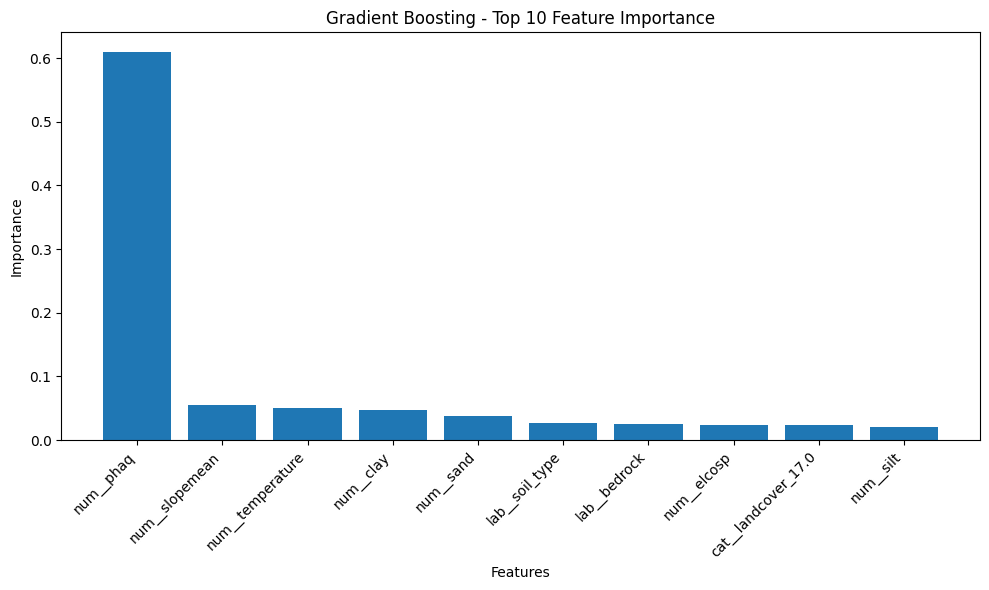


Training MLP...
MSE: 7273.9978
MAE: 51.4471
R2: 0.3749


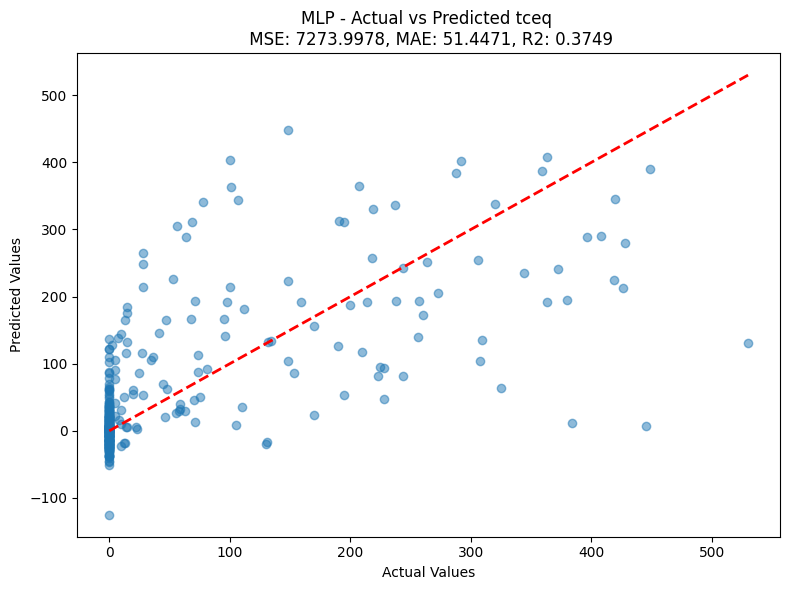

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Define feature types
categorical_cols = ['landcover', 'ecoregion']
label_cols = ['soil_type', 'bedrock']
numeric_cols = [col for col in gdf.columns if col not in categorical_cols + label_cols + [TARGET]]

# Split data first (avoids leakage)
train_df, test_df = train_test_split(gdf, test_size=0.2, random_state=42)

# Preprocessing pipeline
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
label_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('lab', label_transformer, label_cols)
])

# Fit and transform the data
X_train = preprocessor.fit_transform(train_df.drop(columns=[TARGET]))
y_train = train_df[TARGET].values
X_test = preprocessor.transform(test_df.drop(columns=[TARGET]))
y_test = test_df[TARGET].values

# Baseline model (predicting mean value)
y_baseline = np.full_like(y_test, np.mean(y_train))

# Calculate baseline metrics
baseline_mse = mean_squared_error(y_test, y_baseline)
baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_r2 = r2_score(y_test, y_baseline)

print("\nBaseline Model:")
print(f"MSE: {baseline_mse:.4f}")
print(f"MAE: {baseline_mae:.4f}")
print(f"R2: {baseline_r2:.4f}")

# Plot baseline predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_baseline, alpha=0.5, label='Baseline Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Baseline Model - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

# Initialize models
models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(random_state=42, max_iter=1000, hidden_layer_sizes=(100, 50))
}

# Train and evaluate models
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    
    # Plot actual vs predicted
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{name} - Actual vs Predicted {TARGET} \n MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')
    plt.tight_layout()
    plt.show()
    
    # Plot feature importance for tree-based models
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feature_names = preprocessor.get_feature_names_out()
        feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
        feat_importance.sort_values(by='Importance', ascending=False, inplace=True)
        
        plt.figure(figsize=(10, 6))
        plt.bar(feat_importance['Feature'][:10], feat_importance['Importance'][:10])
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Features')
        plt.ylabel('Importance')
        plt.title(f'{name} - Top 10 Feature Importance')
        plt.tight_layout()
        plt.show()

Epoch 1/200


d:\tierra\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 20008.9336 - mae: 63.6930 - val_loss: 17597.1426 - val_mae: 59.9445 - learning_rate: 0.0010
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18545.4688 - mae: 62.7056 - val_loss: 18144.2383 - val_mae: 58.2129 - learning_rate: 0.0010
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19183.3594 - mae: 65.1300 - val_loss: 18384.9258 - val_mae: 59.6250 - learning_rate: 0.0010
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16632.7402 - mae: 61.1569 - val_loss: 18773.0527 - val_mae: 64.3778 - learning_rate: 0.0010
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19218.7637 - mae: 69.1741 - val_loss: 18614.8711 - val_mae: 67.0273 - learning_rate: 0.0010
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15967.7988 - mae: 61.7709 - val_loss: 18729.5078 - val_mae: 70.0200 - learning_rate: 0.0010
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14545.2998 - mae: 59.0077 - val_loss: 18361.357

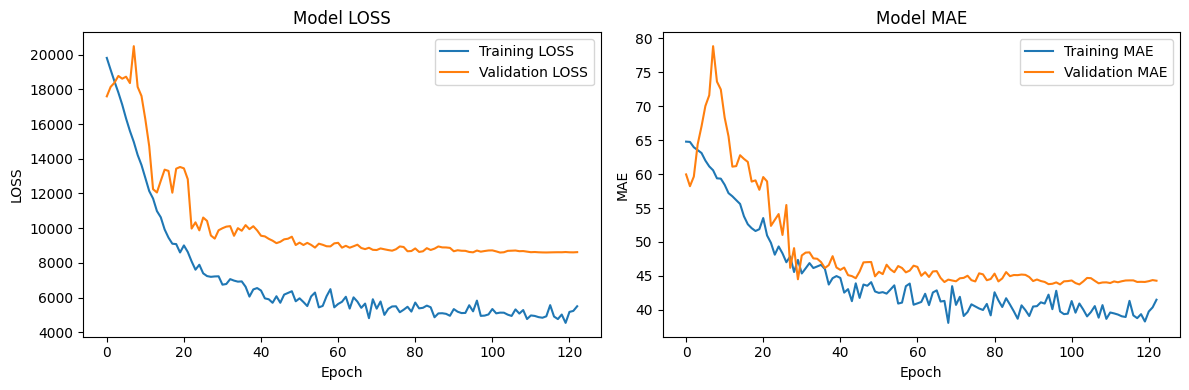

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Model Performance Metrics:
MSE: 6710.6079
MAE: 41.0868
R2 Score: 0.4233


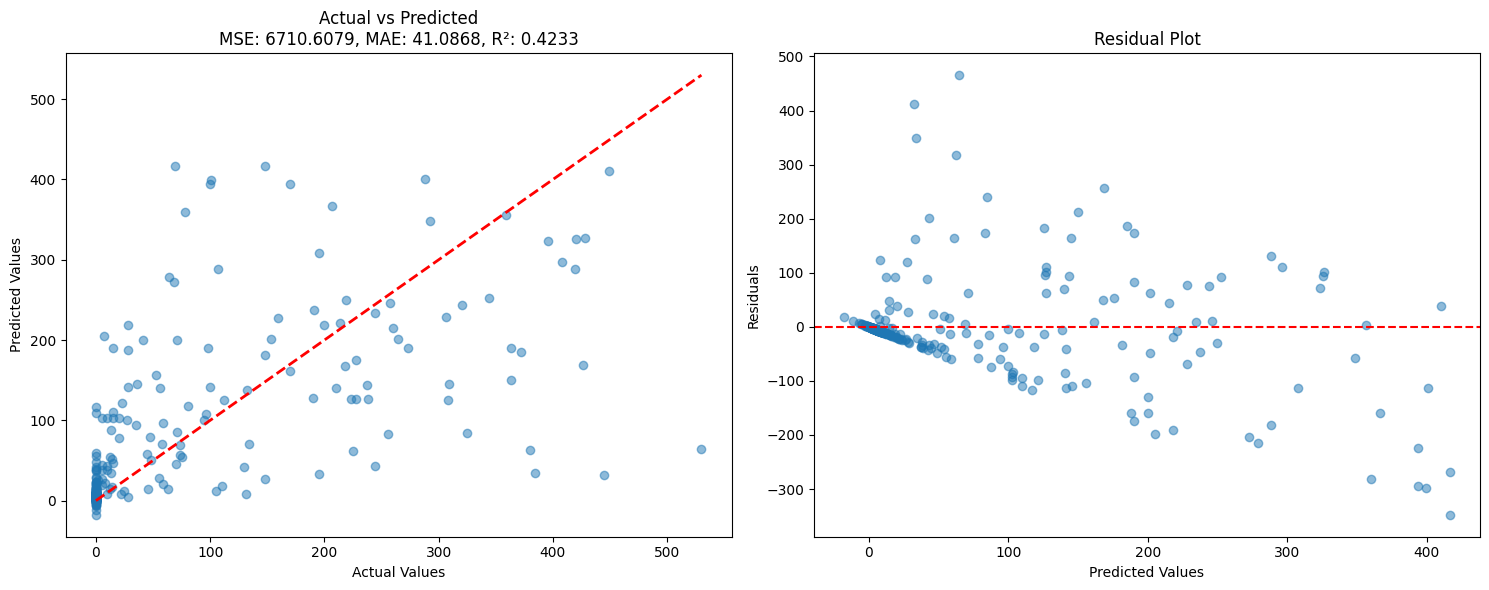

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

def create_dense_block(units, dropout_rate=None, batch_norm=True):
    """Create a reusable dense block with regularization"""
    block = [Dense(units, activation='relu', kernel_regularizer=l2(0.01))]
    if batch_norm:
        block.append(BatchNormalization())
    if dropout_rate:
        block.append(Dropout(dropout_rate))
    return block

def create_model(input_dim, architecture):
    """Create model with flexible architecture"""
    model = tf.keras.Sequential()
    
    # First layer
    model.add(Dense(architecture[0], activation='relu', 
                   kernel_regularizer=l2(0.01), 
                   input_shape=(input_dim,)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Hidden layers
    for units in architecture[1:-1]:
        for layer in create_dense_block(units, dropout_rate=0.2):
            model.add(layer)
    
    # Output layer
    model.add(Dense(1))
    
    return model

def plot_metrics(history, metrics):
    """Plot training metrics"""
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6*n_metrics, 4))
    
    for i, metric in enumerate(metrics):
        ax = axes[i] if n_metrics > 1 else axes
        ax.plot(history.history[metric], label=f'Training {metric.upper()}')
        ax.plot(history.history[f'val_{metric}'], label=f'Validation {metric.upper()}')
        ax.set_title(f'Model {metric.upper()}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.upper())
        ax.legend()
    
    plt.tight_layout()
    plt.show()

def plot_regression_analysis(y_true, y_pred):
    """Plot regression analysis plots"""
    # Calculate metrics
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Print metrics
    print(f'\nModel Performance Metrics:')
    print(f'MSE: {mse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'R2 Score: {r2:.4f}')
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Actual vs Predicted plot
    ax1.scatter(y_true, y_pred, alpha=0.5)
    ax1.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax1.set_xlabel('Actual Values')
    ax1.set_ylabel('Predicted Values')
    ax1.set_title(f'Actual vs Predicted\nMSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}')
    
    # Residuals plot
    residuals = y_true - y_pred.flatten()
    ax2.scatter(y_pred.flatten(), residuals, alpha=0.5)
    ax2.axhline(y=0, color='r', linestyle='--')
    ax2.set_xlabel('Predicted Values')
    ax2.set_ylabel('Residuals')
    ax2.set_title('Residual Plot')
    
    plt.tight_layout()
    plt.show()

# Model configuration
input_dim = X_train.shape[1]
architecture = [256, 128, 64, 32]  # Layer units

# Create and compile model
model = create_model(input_dim, architecture)
model.compile(optimizer=Adam(learning_rate=0.001),
             loss='mse',
             metrics=['mae'])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6)
]

# Train model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Plot training history
plot_metrics(history, ['loss', 'mae'])

# Make predictions and plot analysis
y_pred = model.predict(X_test)
plot_regression_analysis(y_test, y_pred)


Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Random Forest: {'max_depth': 30, 'min_samples_split': 3, 'n_estimators': 287}
Best CV score: 0.5829

Tuning Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Gradient Boosting: {'learning_rate': np.float64(0.0792681476866447), 'max_depth': 6, 'n_estimators': 466}
Best CV score: 0.5503

Tuning MLP...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for MLP: {'alpha': np.float64(0.0006808361216819947), 'hidden_layer_sizes': (50, 50), 'learning_rate': 'adaptive'}
Best CV score: 0.4433

Evaluating tuned models with cross-validation...

Random Forest CV Results:
Mean R²: 0.5829 (+/- 0.0705)
Test MSE: 4651.1348
Test MAE: 33.6303
Test R²: 0.6003


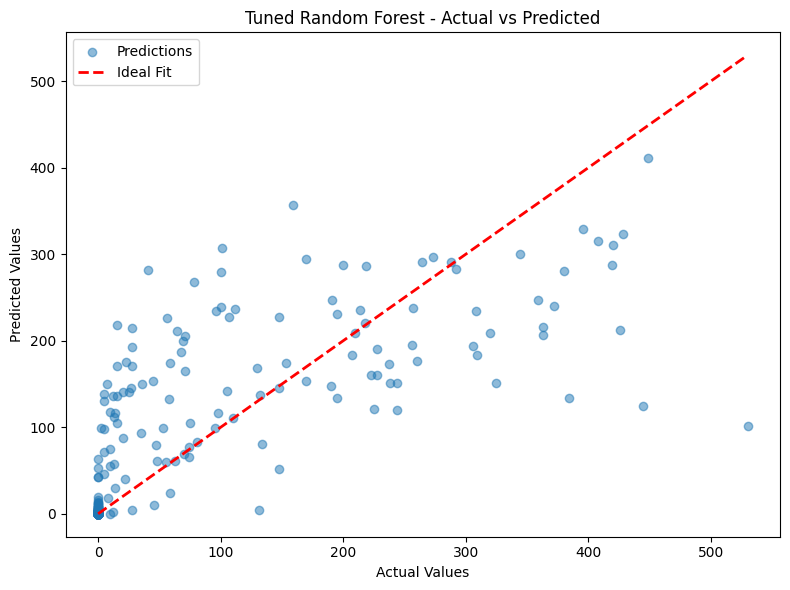

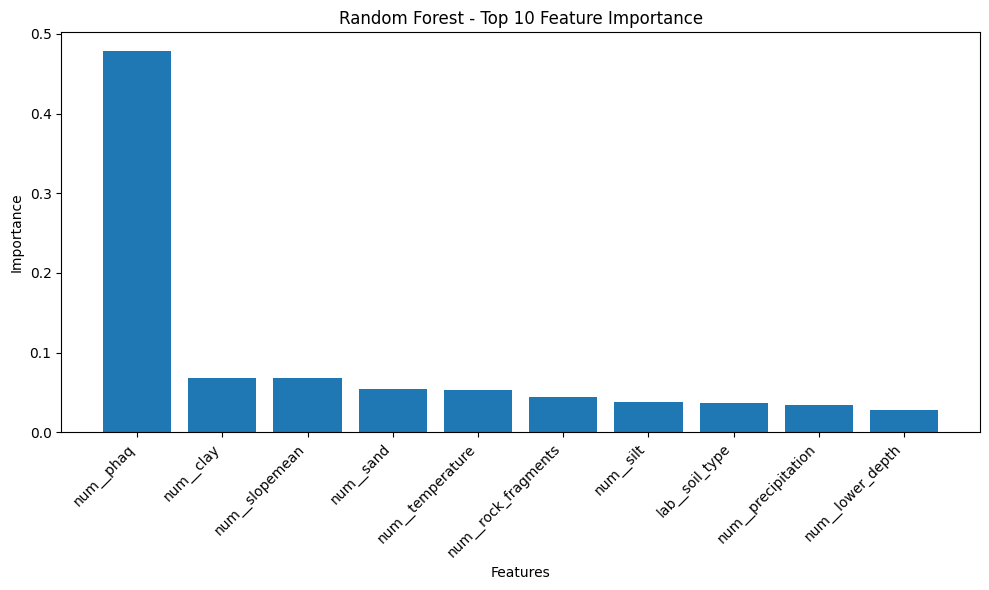


Gradient Boosting CV Results:
Mean R²: 0.5503 (+/- 0.1259)
Test MSE: 6502.1931
Test MAE: 38.5980
Test R²: 0.4412


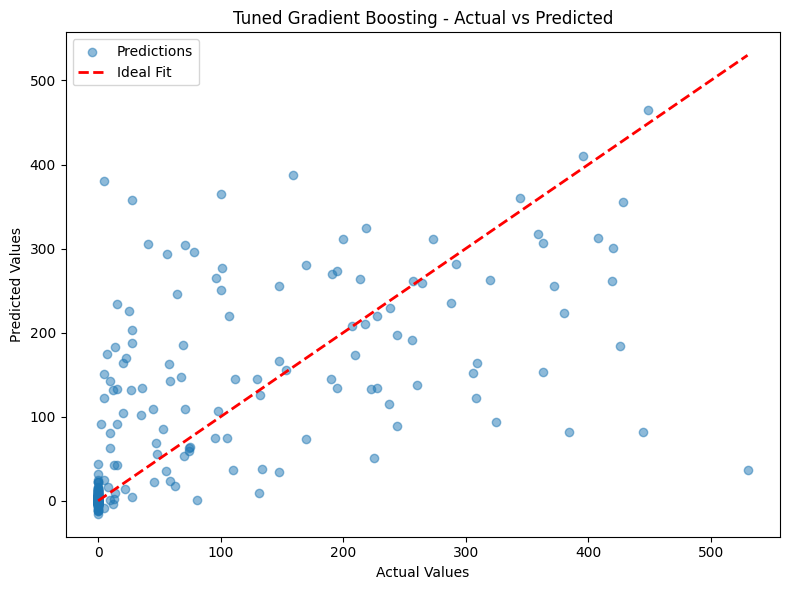

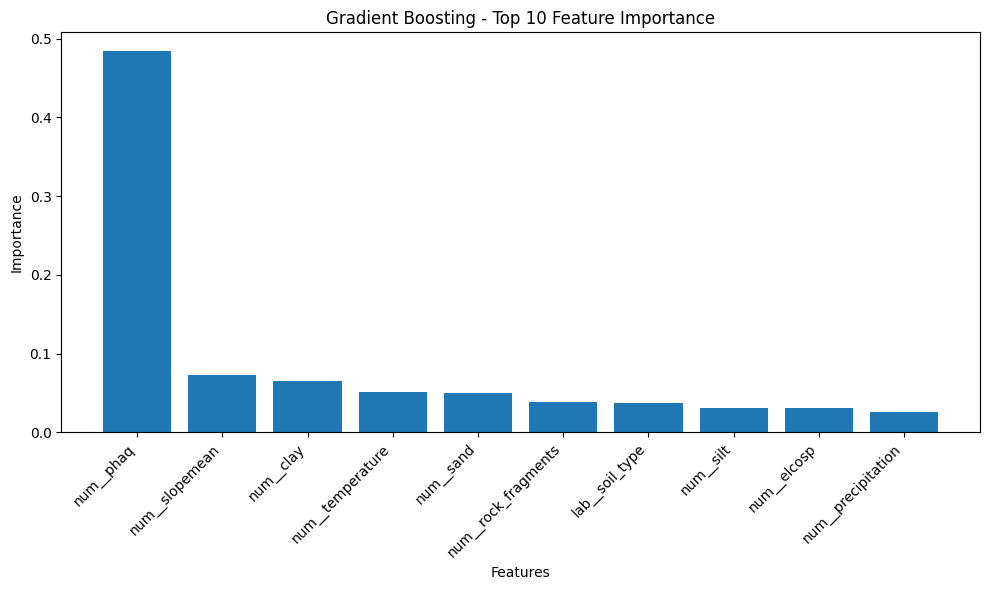


MLP CV Results:
Mean R²: 0.4433 (+/- 0.0404)
Test MSE: 6723.6155
Test MAE: 47.2555
Test R²: 0.4222


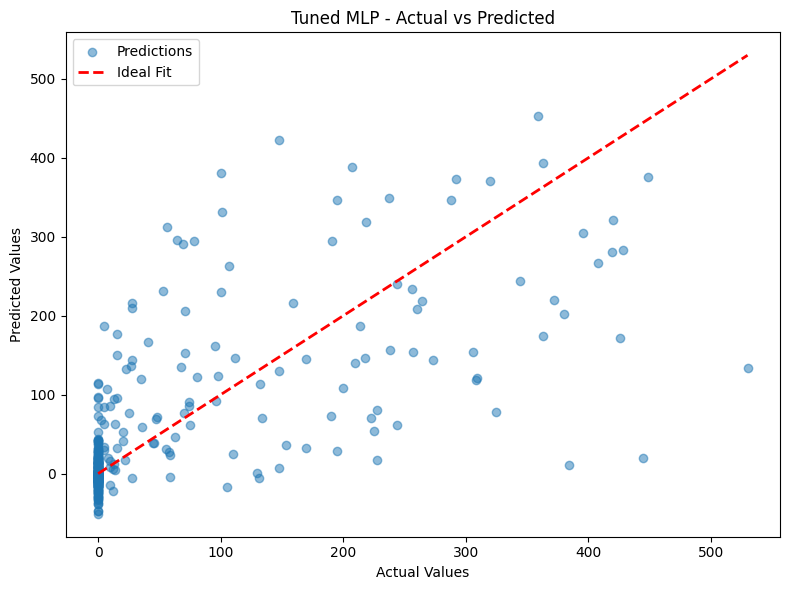

In [7]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import randint, uniform

# Define parameter distributions
param_distributions = {
    'Random Forest': {
        'n_estimators': randint(100, 500),
        'max_depth': [10, 20, 30, None],
        'min_samples_split': randint(2, 10)
    },
    'Gradient Boosting': {
        'n_estimators': randint(100, 500),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 7)
    },
    'MLP': {
        'hidden_layer_sizes': [(50,50), (100,50), (100,100)],
        'alpha': uniform(0.0001, 0.01),
        'learning_rate': ['constant', 'adaptive']
    }
}

# Function for hyperparameter tuning
def tune_model(model, param_dist, name, X_train, y_train, cv=5, n_iter=20):
    print(f"\nTuning {name}...")
    search = RandomizedSearchCV(model, param_dist, cv=cv, n_iter=n_iter, n_jobs=-1, verbose=1, random_state=42)
    search.fit(X_train, y_train)
    print(f"Best parameters for {name}: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.4f}")
    return search.best_estimator_

# Tune models
models = {
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(random_state=42, max_iter=1000)
}

tuned_models = {name: tune_model(model, param_distributions[name], name, X_train, y_train) for name, model in models.items()}

# Evaluate tuned models
print("\nEvaluating tuned models with cross-validation...")
for name, model in tuned_models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\n{name} CV Results:")
    print(f"Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    mse, mae, r2 = mean_squared_error(y_test, y_pred), mean_absolute_error(y_test, y_pred), r2_score(y_test, y_pred)
    print(f"Test MSE: {mse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    print(f"Test R²: {r2:.4f}")
    
    # Plot actual vs predicted
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Tuned {name} - Actual vs Predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Feature importance (for tree-based models)
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feature_names = preprocessor.get_feature_names_out()
        feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
        feat_importance.sort_values(by='Importance', ascending=False, inplace=True)

        plt.figure(figsize=(10, 6))
        plt.bar(feat_importance['Feature'][:10], feat_importance['Importance'][:10])
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Features')
        plt.ylabel('Importance')
        plt.title(f'{name} - Top 10 Feature Importance')
        plt.tight_layout()
        plt.show()